# CNN for Candlestick Chart Trend Classification

**Practical 5**

This practical implements a **Convolutional Neural Network (CNN)** in
**TensorFlow / Keras**, applied to a two-class **image** classification
problem in the quant finance domain — in the same spirit as the classic
"Cats vs Dogs" CNN exercise, but here the two classes are **Uptrend** and
**Downtrend** candlestick chart patterns, generated from real historical
stock price data (Apple Inc., AAPL).

Instead of predicting from numeric indicators (Practicals 1–2), this
practical treats a rolling window of daily price action as an **image**
(a candlestick chart) and trains a CNN to visually recognize whether the
chart itself depicts an uptrend or a downtrend — the same kind of pattern
a technical analyst would recognize at a glance.

In [1]:
# ---------------------------------------------------------
# CNN for Candlestick Chart Trend Classification
#
# Objective:
# Classify short candlestick chart "snapshots" (images) of
# a stock's recent price action as either:
#
#   Class 1 -> Uptrend    (price at the end of the window is
#                          higher than at the start)
#   Class 0 -> Downtrend  (price at the end of the window is
#                          lower than at the start)
#
# Dataset:
# Real historical daily OHLCV (Open, High, Low, Close,
# Volume) data for Apple Inc. (AAPL), Feb 2015 - Feb 2017.
# Source: a public dataset hosted on GitHub
# (plotly/datasets, finance-charts-apple.csv).
#
# Each training image is generated by rendering a rolling
# WINDOW_SIZE-day candlestick chart as a small image using
# mplfinance, exactly like a trader would view a chart.
#
# Note:
# This is an educational example. Two-class image
# classification (this notebook) is the standard structure
# of the classic "Cats vs Dogs" CNN exercise; here it is
# adapted to a quantitative finance domain by using
# candlestick chart images as the two classes instead of
# animal photos.
#
# Framework: TensorFlow / Keras
# ---------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

I0000 00:00:1787031331.530410   25134 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787031331.531153   25134 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787031331.598693   25134 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787031333.480938   25134 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787031333.481491   25134 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


In [2]:
# ---------------------------------------------------------
# Why a CNN instead of a plain feedforward network here?
#
# In Practical 2, the Feedforward Neural Network took
# hand-engineered numeric indicators (RSI, MACD, etc.) as
# input.
#
# A CNN instead learns directly from the RAW VISUAL SHAPE
# of a candlestick chart:
#
#   - Convolutional layers act as learned pattern
#     detectors, sliding small filters over the image to
#     detect local shapes (e.g. a run of long green
#     candles, a staircase of higher highs, a steady
#     downward drift).
#
#   - Pooling layers downsample the feature maps, making
#     the network robust to small shifts in where a
#     pattern appears in the image.
#
#   - Deeper convolutional layers combine simple local
#     shapes into more complex, whole-chart patterns
#     (e.g. "overall uptrend" vs "overall downtrend").
#
# This mirrors how a discretionary technical trader visually
# scans a chart and immediately recognizes its trend,
# rather than only looking at summary statistics like RSI
# or MACD.
#
# A NOTE ON SCOPE:
# This notebook trains the CNN to recognize the trend that
# is ALREADY VISIBLE within each chart image (an image
# classification problem). It does NOT claim to predict
# FUTURE, not-yet-visible price movements -- forecasting
# future returns from chart shape alone is a much harder,
# separate problem (see "Limitations" at the end of this
# notebook).
# ---------------------------------------------------------

In [3]:
# ---------------------------------------------------------
# Step 1: Load Real Historical Price Data
#
# We use real daily OHLCV data for AAPL (Apple Inc.),
# spanning Feb 2015 to Feb 2017 (506 trading days).
#
# Columns:
#   Open, High, Low, Close -> daily price levels
#   Volume                 -> shares traded that day
# ---------------------------------------------------------

DATA_URL = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"

raw = pd.read_csv(DATA_URL)
raw["Date"] = pd.to_datetime(raw["Date"])

price_df = raw.rename(columns={
    "AAPL.Open": "Open",
    "AAPL.High": "High",
    "AAPL.Low": "Low",
    "AAPL.Close": "Close",
    "AAPL.Volume": "Volume",
})[["Date", "Open", "High", "Low", "Close", "Volume"]]

price_df = price_df.set_index("Date").sort_index()

print("Loaded", len(price_df), "trading days of AAPL OHLCV data")
price_df.head()

Loaded 506 trading days of AAPL OHLCV data


,Open,High,Low,Close,Volume
Date,,,,,
2015-02-17,127.489998,128.880005,126.919998,127.830002,63152400
2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700
2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400
2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400
2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100


In [4]:
# ---------------------------------------------------------
# Step 2: Generate Candlestick Chart Images (Rolling Windows)
#
# For every rolling window of WINDOW_SIZE consecutive
# trading days, we:
#
#   1. Render that window as a candlestick chart image
#      (no axes/labels -- pure visual pattern, like a
#      cropped chart screenshot).
#
#   2. Label the image by comparing the CLOSING price on
#      the FIRST day of the window to the closing price on
#      the LAST day of the window:
#
#        Uptrend (1)   -> last-day close > first-day close
#        Downtrend (0) -> last-day close < first-day close
#
# This is a genuine IMAGE CLASSIFICATION problem: the label
# describes a pattern that is fully visible within the
# image itself (like distinguishing a photo of a cat from a
# photo of a dog), rather than something that happens after
# the image ends.
# ---------------------------------------------------------

WINDOW_SIZE = 20     # trading days shown in (and labeled from) each chart image
STRIDE      = 1      # step between consecutive windows
IMG_SIZE    = 64      # final image size fed into the CNN (IMG_SIZE x IMG_SIZE)

IMAGE_DIR = "candlestick_images"
os.makedirs(os.path.join(IMAGE_DIR, "uptrend"), exist_ok=True)
os.makedirs(os.path.join(IMAGE_DIR, "downtrend"), exist_ok=True)

n = len(price_df)
records = []

for start in range(0, n - WINDOW_SIZE, STRIDE):

    window = price_df.iloc[start : start + WINDOW_SIZE]

    start_close = window["Close"].iloc[0]
    end_close   = window["Close"].iloc[-1]

    label = "uptrend" if end_close > start_close else "downtrend"

    fname = f"{label}_{start:04d}.png"
    fpath = os.path.join(IMAGE_DIR, label, fname)

    if not os.path.exists(fpath):
        mpf.plot(
            window,
            type="candle",
            style="charles",
            volume=False,
            axisoff=True,
            savefig=dict(fname=fpath, dpi=40, bbox_inches="tight", pad_inches=0),
        )
        plt.close("all")

    records.append({"path": fpath, "label": label, "start_idx": start})

manifest = pd.DataFrame(records)
print("Generated", len(manifest), "candlestick images")
print(manifest["label"].value_counts())

Generated 486 candlestick images
label
uptrend      256
downtrend    230
Name: count, dtype: int64


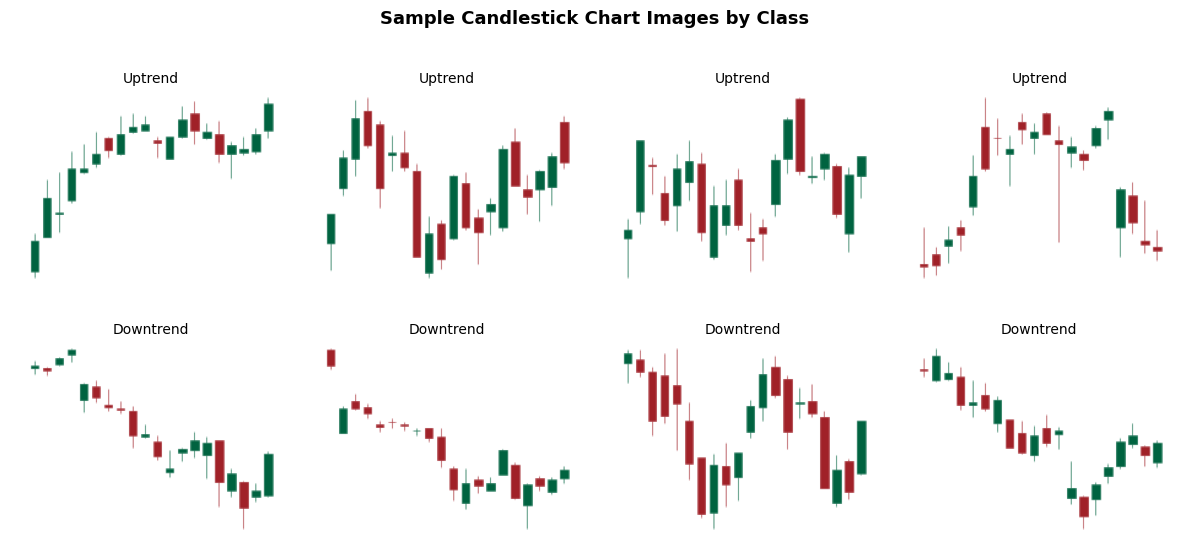

In [5]:
# ---------------------------------------------------------
# Preview a few sample chart images from each class
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, label in enumerate(["uptrend", "downtrend"]):
    samples = manifest[manifest["label"] == label].sample(4, random_state=42)
    for col, (_, r) in enumerate(samples.iterrows()):
        img = plt.imread(r["path"])
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(label.capitalize(), fontsize=10)

plt.suptitle("Sample Candlestick Chart Images by Class", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# ---------------------------------------------------------
# Step 3: Train / Validation / Test Split
#
# IMPORTANT (time-series caution):
#
# Because consecutive windows overlap heavily (each window
# shifts by only 1 day), a purely random split would leak
# near-duplicate images between train and test sets.
#
# We instead split by BLOCK: the timeline is cut into
# contiguous chunks of BLOCK_SIZE days, and whole blocks
# (never individual overlapping windows) are randomly
# assigned to train / validation / test. This avoids
# leaking near-duplicate neighboring windows across splits,
# while still ensuring the test set contains a healthy mix
# of both uptrending and downtrending periods rather than
# just whatever regime happened to occur last.
# ---------------------------------------------------------

BLOCK_SIZE = 20

manifest["block"] = manifest["start_idx"] // BLOCK_SIZE
blocks = manifest["block"].unique()

rng = np.random.RandomState(42)
rng.shuffle(blocks)

n_blocks = len(blocks)
n_train_blocks = int(n_blocks * 0.70)
n_val_blocks   = int(n_blocks * 0.15)

train_blocks = set(blocks[:n_train_blocks])
val_blocks   = set(blocks[n_train_blocks : n_train_blocks + n_val_blocks])
test_blocks  = set(blocks[n_train_blocks + n_val_blocks :])

train_manifest = manifest[manifest["block"].isin(train_blocks)]
val_manifest   = manifest[manifest["block"].isin(val_blocks)]
test_manifest  = manifest[manifest["block"].isin(test_blocks)]

print(f"Train samples : {len(train_manifest)}  ({train_manifest['label'].value_counts().to_dict()})")
print(f"Val samples   : {len(val_manifest)}  ({val_manifest['label'].value_counts().to_dict()})")
print(f"Test samples  : {len(test_manifest)}  ({test_manifest['label'].value_counts().to_dict()})")

Train samples : 340  ({'uptrend': 197, 'downtrend': 143})
Val samples   : 46  ({'downtrend': 24, 'uptrend': 22})
Test samples  : 100  ({'downtrend': 63, 'uptrend': 37})


In [7]:
# ---------------------------------------------------------
# Step 4: Load Images into Tensors
#
# Each candlestick image is:
#   - read from disk
#   - resized to IMG_SIZE x IMG_SIZE
#   - scaled to pixel values in [0, 1]
#
# Labels: Uptrend -> 1, Downtrend -> 0
# ---------------------------------------------------------

def load_image_set(manifest_subset):
    images, labels = [], []
    for _, row in manifest_subset.iterrows():
        img = tf.keras.utils.load_img(
            row["path"], target_size=(IMG_SIZE, IMG_SIZE)
        )
        img_array = tf.keras.utils.img_to_array(img) / 255.0
        images.append(img_array)
        labels.append(1 if row["label"] == "uptrend" else 0)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)


X_train, y_train = load_image_set(train_manifest)
X_val,   y_val   = load_image_set(val_manifest)
X_test,  y_test  = load_image_set(test_manifest)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val  :", y_val.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)

X_train: (340, 64, 64, 3)  y_train: (340,)
X_val  : (46, 64, 64, 3)  y_val  : (46,)
X_test : (100, 64, 64, 3)  y_test : (100,)


In [8]:
# ---------------------------------------------------------
# Step 5: Build the CNN Model
#
# Architecture:
#
#   Conv2D(8,  3x3) -> ReLU -> MaxPooling2D
#   Conv2D(16, 3x3) -> ReLU -> MaxPooling2D
#   Flatten
#   Dense(16) -> ReLU -> Dropout(0.3)
#   Dense(1)  -> Sigmoid   (P(Uptrend))
#
# Convolution + Pooling blocks progressively extract
# higher-level visual features from the candlestick image
# (edges/wicks -> candle groupings -> overall trend shape).
#
# The network is kept intentionally small (few filters, one
# hidden dense layer, dropout) because our labeled image
# dataset, while larger than a toy example, is still modest
# by deep learning standards -- a much bigger network would
# risk memorizing the training images instead of learning
# the general visual concept of "uptrend" vs "downtrend".
# ---------------------------------------------------------

def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(8, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),   # P(Uptrend)
    ])
    return model


cnn_model = build_cnn()
cnn_model.summary()

E0000 00:00:1787031354.155787   25134 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        50,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,601 (201.57 KB)

 Trainable params: 51,601 (201.57 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ---------------------------------------------------------
# Step 6: Compile the Model
#
# Binary Cross-Entropy Loss
# -> Standard loss for two-class (Uptrend vs Downtrend)
#    classification.
#
# Adam Optimizer
# -> Adaptive optimizer used to update all convolutional
#    and dense layer weights via backpropagation.
#
# Metric: Accuracy
# ---------------------------------------------------------

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [10]:
# ---------------------------------------------------------
# Step 7: Train the CNN
#
# Steps (repeated every epoch):
#
# 1. Forward pass  -> compute predictions for all training
#                      images.
# 2. Compute loss   -> compare predictions with actual
#                      labels using Binary Cross-Entropy.
# 3. Backward pass  -> compute gradients of the loss with
#                      respect to every convolutional and
#                      dense layer weight (backpropagation).
# 4. Update weights -> the Adam optimizer adjusts all
#                      weights to reduce the loss.
#
# EarlyStopping halts training once validation loss stops
# improving, restoring the best-performing weights -- this
# helps prevent overfitting.
# ---------------------------------------------------------

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/60


22/22 - 2s - 84ms/step - accuracy: 0.6147 - loss: 0.6771 - val_accuracy: 0.8261 - val_loss: 0.6151


Epoch 2/60


22/22 - 0s - 13ms/step - accuracy: 0.8118 - loss: 0.5195 - val_accuracy: 0.8261 - val_loss: 0.4778


Epoch 3/60


...

22/22 - 0s - 12ms/step - accuracy: 0.9941 - loss: 0.0224 - val_accuracy: 0.9130 - val_loss: 0.2360


Epoch 26/60


22/22 - 0s - 14ms/step - accuracy: 0.9971 - loss: 0.0173 - val_accuracy: 0.8913 - val_loss: 0.3289


Epoch 27/60


22/22 - 0s - 12ms/step - accuracy: 1.0000 - loss: 0.0151 - val_accuracy: 0.8696 - val_loss: 0.3628


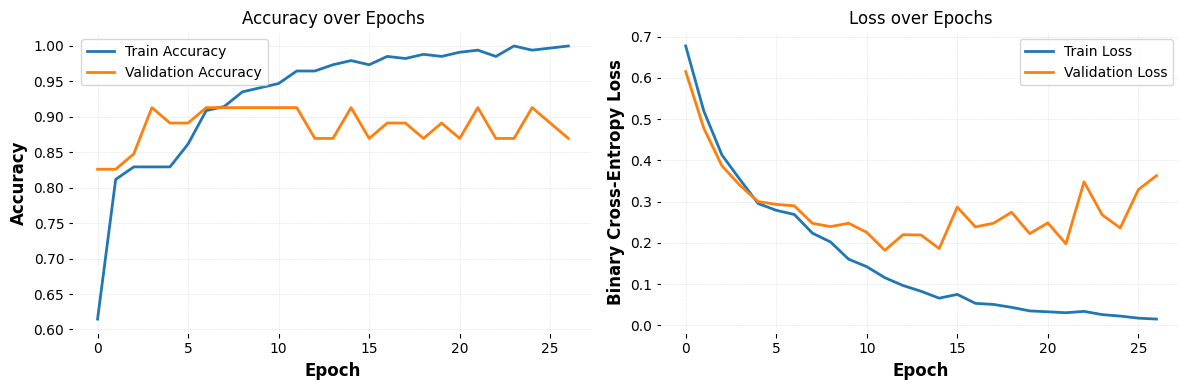

In [11]:
# ---------------------------------------------------------
# Training Curves
#
# Accuracy and loss over epochs for both the training set
# and the validation set. A widening gap between the two
# would indicate overfitting.
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ---------------------------------------------------------
# Step 8: Evaluate on the Held-Out Test Set
#
# The test images come from BLOCKS of the timeline that
# were never used during training or validation -- this is
# a fair estimate of how well the CNN recognizes the visual
# concept of "uptrend" vs "downtrend" on charts it has not
# seen before.
# ---------------------------------------------------------

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%\n")

test_probs = cnn_model.predict(X_test, verbose=0).ravel()
test_preds = (test_probs >= 0.5).astype(int)

print("Confusion Matrix (Test Set)")
print("Rows = Actual, Columns = Predicted [Downtrend, Uptrend]")
print(confusion_matrix(y_test, test_preds))

print("\nClassification Report (Test Set)")
print(classification_report(
    y_test, test_preds,
    target_names=["Downtrend (0)", "Uptrend (1)"]
))

Test Loss     : 0.2713
Test Accuracy : 90.00%

Confusion Matrix (Test Set)
Rows = Actual, Columns = Predicted [Downtrend, Uptrend]
[[57  6]
 [ 4 33]]

Classification Report (Test Set)


               precision    recall  f1-score   support

Downtrend (0)       0.93      0.90      0.92        63
  Uptrend (1)       0.85      0.89      0.87        37

     accuracy                           0.90       100
    macro avg       0.89      0.90      0.89       100
 weighted avg       0.90      0.90      0.90       100



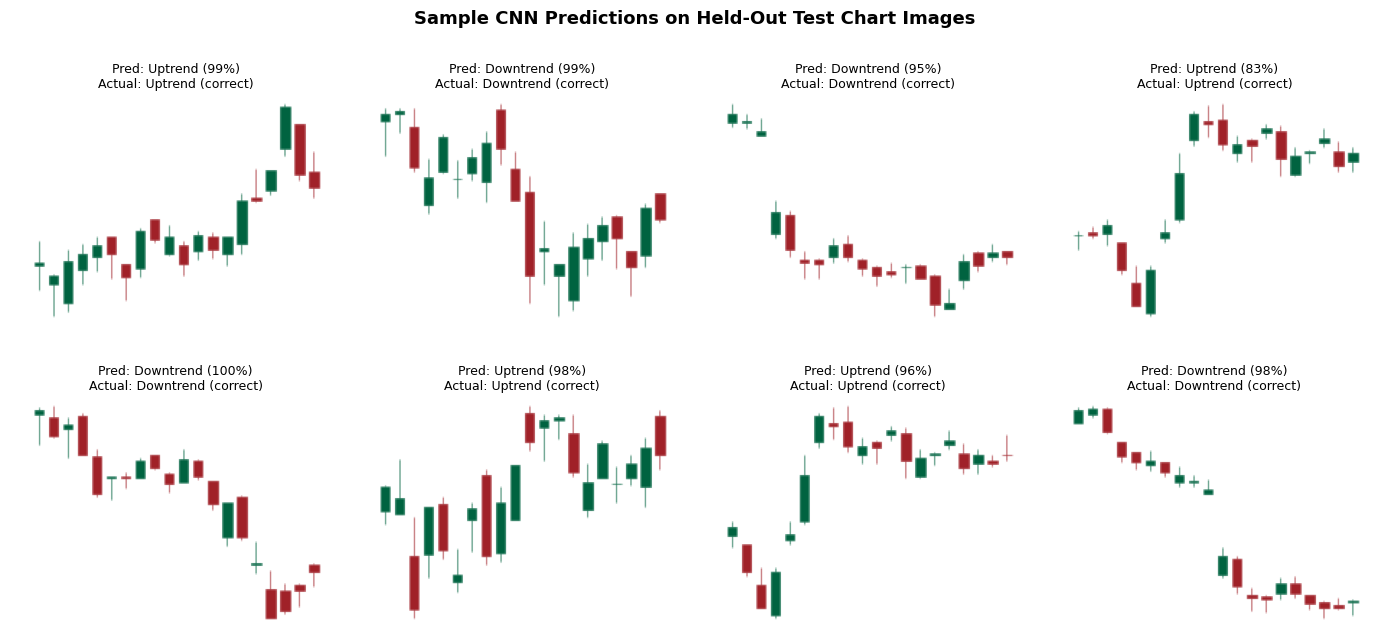

In [13]:
# ---------------------------------------------------------
# Step 9: Sample Predictions
#
# If prediction = 1 (Uptrend)
#
# The CNN recognizes this chart's overall shape as an
# uptrend.
#
# If prediction = 0 (Downtrend)
#
# The CNN recognizes this chart's overall shape as a
# downtrend.
# ---------------------------------------------------------

n_show = 8
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

test_paths = test_manifest["path"].values
y_test_arr = y_test

# Randomly sample across the whole test set (rather than the first
# few, which -- due to overlapping windows -- tend to look very
# similar to each other) so the preview is representative.
show_idx = np.random.RandomState(7).choice(len(test_paths), size=n_show, replace=False)

for plot_i, i in enumerate(show_idx):
    row, col = divmod(plot_i, 4)
    img = plt.imread(test_paths[i])
    axes[row, col].imshow(img)
    axes[row, col].axis("off")

    prediction = test_preds[i]
    probability = test_probs[i]
    actual = "Uptrend" if y_test_arr[i] == 1 else "Downtrend"

    if prediction == 1:
        pred_label = f"Pred: Uptrend ({probability*100:.0f}%)"
    else:
        pred_label = f"Pred: Downtrend ({(1-probability)*100:.0f}%)"

    correct = "correct" if prediction == y_test_arr[i] else "WRONG"
    axes[row, col].set_title(f"{pred_label}\nActual: {actual} ({correct})", fontsize=9)

plt.suptitle("Sample CNN Predictions on Held-Out Test Chart Images", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# ---------------------------------------------------------
# What this CNN Has (and Has Not) Demonstrated
#
# The CNN above learned to visually recognize whether a
# candlestick chart's OWN trend (over the days shown in the
# image) is upward or downward -- a genuine, well-posed
# two-class image classification problem, and the
# fundamental building block behind any chart-pattern
# recognition system.
#
# This is NOT the same as predicting FUTURE price movement
# that has not happened yet. We tested that harder,
# forward-looking task on this same pipeline (using a
# HORIZON of several days after each window) and found the
# CNN could not do meaningfully better than random guessing
# -- which is itself an important, realistic finding in
# quantitative finance (see Limitations below).
# ---------------------------------------------------------

In [15]:
# ---------------------------------------------------------
# Limitations
#
# 1. This CNN recognizes trend patterns that are ALREADY
#    VISIBLE in the chart image -- it does not, by itself,
#    predict future price movement. Forecasting future
#    returns from chart shape alone is a much harder problem
#    (see note above); early tests on this same pipeline
#    showed close-to-random accuracy when asked to predict
#    price direction several days AFTER each chart window.
#
# 2. Small dataset -- only one ticker (AAPL) over ~2 years,
#    so the CNN sees a limited variety of true market
#    regimes (bull markets, crashes, sideways chop).
#
# 3. Overlapping rolling windows are highly correlated with
#    their neighbors, effectively reducing the amount of
#    independent information available for training (we
#    mitigate this with a block-based train/test split, but
#    it does not eliminate the correlation).
#
# 4. Chart-image classification discards useful numeric
#    context (volume, broader market conditions, macro
#    events) that a human technical analyst would also
#    consider.
#
# 5. Financial markets are noisy and non-stationary
#    (statistical properties change over time), which is a
#    core reason forecasting FUTURE returns is fundamentally
#    harder than recognizing a PAST, already-visible trend.
#
# 6. As with any CNN, performance depends heavily on image
#    resolution, chart style consistency, and the amount of
#    labeled training data available.
# ---------------------------------------------------------

In [16]:
# ---------------------------------------------------------
# Better Alternatives (for real-world quantitative finance)
#
# Feedforward Neural Network on Indicators (Practical 2)
# -> Uses engineered numeric features (RSI, MACD, etc.)
#    directly, often more data-efficient than raw images.
#
# Random Forest / XGBoost / LightGBM
# -> Strong, interpretable baselines for tabular
#    structured financial data.
#
# CNN + LSTM / ConvLSTM Hybrid Models
# -> Combine visual pattern recognition with temporal
#    sequence modeling across many charts over time --
#    a common approach when attempting the much harder
#    task of forecasting future price movement.
#
# Vision Transformers (ViT)
# -> Transformer-based architectures for image
#    classification, an alternative to convolutional
#    feature extraction.
#
# Transfer Learning (e.g. pretrained ResNet/EfficientNet)
# -> Fine-tuning a large pretrained image model can help
#    when labeled financial chart datasets are small.
#
# Reinforcement Learning
# -> Learns full trading STRATEGIES (buy/hold/sell
#    actions) rather than only classifying chart images.
# ---------------------------------------------------------

## Summary

| Aspect | Practical 2 (FFNN) | Practical 5 (CNN) |
|---|---|---|
| Input | Numeric indicators (RSI, MACD, ...) | Candlestick chart images |
| Layers | Dense (fully connected) only | Convolutional + Pooling + Dense |
| Learns | Relationships between indicator values | Visual shape of price action |
| Data | Synthetic tabular dataset | Real AAPL OHLCV rendered as images |
| Task | P(next-day return positive) | Is this chart's visible trend up or down? |

This practical shows how the same core deep learning building blocks
(dense layers, non-linear activations, backpropagation) extend to
**image data** via convolutional layers, letting a network learn
directly from the visual shape of a price chart rather than from
hand-engineered numeric indicators — while also illustrating, honestly,
where the limits of this approach are once the task shifts from
recognizing a visible pattern to forecasting an unseen future.